In [6]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

/data/home/arham/LowASRBackdoor


In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
from PIL import Image
from utils.aggregate_block.model_trainer_generate import generate_cls_model
from utils.aggregate_block.dataset_and_transform_generate import get_dataset_normalization

In [76]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL_PATH = "../record/20260629_182416_badnet_attack_badnet_6MrG/final_state_dict.pth"
TRIGGER_PATH = "../resource/badnet/trigger_image.png"
TARGET_LABEL = 0
DESIRED_ASR = 0.12
BATCH_SIZE = 128
MEAN = 0.5
STD = 0.5
LR = 5e-6
EPOCHS = 60
REVERSE_RATIO = 0.05
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [77]:
# ------------------------------------------------------------
# LOAD PATCH TRIGGER
# ------------------------------------------------------------
def load_patch_trigger(trigger_path, device, img_size=28):
    trigger_img = Image.open(trigger_path).convert("L")
    trigger_img = trigger_img.resize((img_size, img_size))

    trigger_raw = transforms.ToTensor()(trigger_img)   # values [0, 1]

    # mask before normalization
    trigger_mask = trigger_raw > 0

    # normalize trigger
    trigger_norm = (trigger_raw - 0.5) / 0.5

    return trigger_norm.unsqueeze(0).to(device), trigger_mask.unsqueeze(0).to(device)

# ------------------------------------------------------------
# PATCH FUNCTION
# ------------------------------------------------------------
def add_patch_trigger(x, trigger_tensor, trigger_mask):
    out = x.clone()

    trigger_batch = trigger_tensor.repeat(x.size(0), 1, 1, 1)
    mask_batch = trigger_mask.repeat(x.size(0), 1, 1, 1)

    out[mask_batch] = trigger_batch[mask_batch]

    return out


# ------------------------------------------------------------
# UNNORMALIZE FUNCTION FOR DISPLAY
# ------------------------------------------------------------
def unnormalize_mnist(x):
    # reverse Normalize(mean=[0.5], std=[0.5])
    return x * MEAN + STD



# ------------------------------------------------------------
# ASR COMPUTATION
# ------------------------------------------------------------
@torch.no_grad()
def compute_asr(model, test_loader, trigger, trigger_mask):
    model.eval()

    success = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        mask = y != TARGET_LABEL

        if mask.sum() == 0:
            continue

        x = x[mask]

        x_trigger = add_patch_trigger(x, trigger, trigger_mask)

        preds = model(x_trigger).argmax(1)

        success += (preds == TARGET_LABEL).sum().item()
        total += x.size(0)

    return success / total


# ------------------------------------------------------------
# CLEAN ACCURACY
# ------------------------------------------------------------
@torch.no_grad()
def compute_clean(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        preds = model(x).argmax(1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return correct / total

In [78]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

trigger, trigger_mask = load_patch_trigger(TRIGGER_PATH, DEVICE, img_size=28)


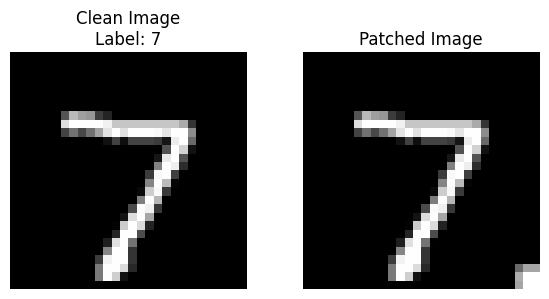

In [79]:
# ------------------------------------------------------------
# PICK ONE IMAGE AND ADD TRIGGER
# ------------------------------------------------------------
index = 0
clean_img, label = test_dataset[index]
clean_batch = clean_img.unsqueeze(0).to(DEVICE)                  # shape: (1, 28, 28) -> (1, 1, 28, 28)
patched_batch = add_patch_trigger(clean_batch, trigger, trigger_mask)
patched_img = patched_batch.squeeze(0).cpu()


# ------------------------------------------------------------
# DISPLAY CLEAN VS PATCHED IMAGE
# ------------------------------------------------------------
clean_display = unnormalize_mnist(clean_img).squeeze(0)
patched_display = unnormalize_mnist(patched_img).squeeze(0)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title(f"Clean Image\nLabel: {label}")
plt.imshow(clean_display, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Patched Image")
plt.imshow(patched_display, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
model = generate_cls_model(
    model_name="simplecnn",
    num_classes=10,
    image_size=28,
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)

# ------------------------------------------------------------
# LOSS + OPTIMIZER
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4,
)


# ------------------------------------------------------------
# REVERSE TRAINING
# ------------------------------------------------------------
for epoch in range(EPOCHS):
    model.train()

    for x, y in tqdm(train_loader):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        bs = x.size(0)
        num_reverse = int(bs * REVERSE_RATIO)

        perm = torch.randperm(bs, device=DEVICE)
        reverse_idx = perm[:num_reverse]

        x_reverse = x[reverse_idx]
        y_reverse = y[reverse_idx]

        x_trigger = add_patch_trigger(x_reverse, trigger, trigger_mask)

        pred_trigger = model(x_trigger)
        loss = criterion(pred_trigger, y_reverse)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    asr = compute_asr(model, test_loader, trigger, trigger_mask)
    clean = compute_clean(model, test_loader)

    print(f"Epoch {epoch} | Clean Acc: {clean:.4f} | ASR: {asr:.4f}")

    if asr <= DESIRED_ASR:
        print("Target ASR achieved")
        break

torch.save(model.state_dict(), "mnist_patch_low_asr_model.pth")

100%|██████████| 469/469 [00:02<00:00, 201.48it/s]


Epoch 0 | Clean Acc: 0.9831 | ASR: 0.0744
Target ASR achieved


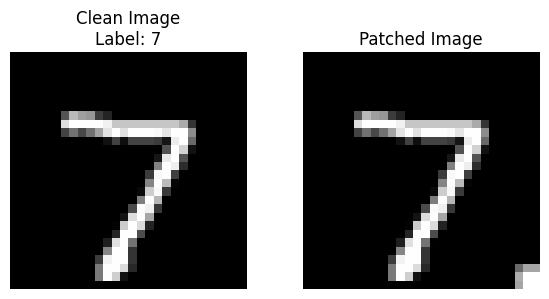

Before training | Clean Acc: 0.9896 | ASR: 1.0000


 11%|█         | 50/469 [00:00<00:02, 144.15it/s]


Epoch 0 | Steps: 50 | Clean Acc: 0.9898 | ASR: 1.0000


 11%|█         | 50/469 [00:00<00:03, 119.62it/s]


Epoch 1 | Steps: 50 | Clean Acc: 0.9901 | ASR: 1.0000


...

Epoch 37 | Steps: 50 | Clean Acc: 0.9845 | ASR: 0.1375


 11%|█         | 50/469 [00:00<00:02, 144.52it/s]


Epoch 38 | Steps: 50 | Clean Acc: 0.9844 | ASR: 0.1242


 11%|█         | 50/469 [00:00<00:02, 145.84it/s]


Epoch 39 | Steps: 50 | Clean Acc: 0.9840 | ASR: 0.1147
Target ASR achieved
Model saved: mnist_patch_low_asr_model.pth


In [83]:
import sys
sys.path = ["../"] + sys.path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm

from utils.aggregate_block.model_trainer_generate import generate_cls_model
from utils.aggregate_block.dataset_and_transform_generate import get_dataset_normalization


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL_PATH = "../record/20260629_182416_badnet_attack_badnet_6MrG/final_state_dict.pth"
TRIGGER_PATH = "../resource/badnet/trigger_image.png"

TARGET_LABEL = 0
DESIRED_ASR = 0.12

BATCH_SIZE = 128
EPOCHS = 60

MEAN = 0.5
STD = 0.5

LR = 1e-6
REVERSE_RATIO = 0.05
REVERSE_STEPS_PER_EPOCH = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# TRIGGER FUNCTIONS
# ------------------------------------------------------------
def load_patch_trigger(trigger_path, device, img_size=28):
    trigger_img = Image.open(trigger_path).convert("L")
    trigger_img = trigger_img.resize((img_size, img_size))

    trigger_raw = transforms.ToTensor()(trigger_img)

    trigger_mask = trigger_raw > 0
    trigger_norm = (trigger_raw - MEAN) / STD

    return trigger_norm.unsqueeze(0).to(device), trigger_mask.unsqueeze(0).to(device)


def add_patch_trigger(x, trigger_tensor, trigger_mask):
    out = x.clone()

    trigger_batch = trigger_tensor.repeat(x.size(0), 1, 1, 1)
    mask_batch = trigger_mask.repeat(x.size(0), 1, 1, 1)

    out[mask_batch] = trigger_batch[mask_batch]

    return out


def unnormalize_mnist(x):
    return x * STD + MEAN


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
@torch.no_grad()
def compute_asr(model, test_loader, trigger, trigger_mask):
    model.eval()

    success = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        mask = y != TARGET_LABEL
        if mask.sum() == 0:
            continue

        x = x[mask]
        x_trigger = add_patch_trigger(x, trigger, trigger_mask)

        preds = model(x_trigger).argmax(1)

        success += (preds == TARGET_LABEL).sum().item()
        total += x.size(0)

    return success / total


@torch.no_grad()
def compute_clean(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        preds = model(x).argmax(1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return correct / total


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
)


# ------------------------------------------------------------
# LOAD TRIGGER
# ------------------------------------------------------------
trigger, trigger_mask = load_patch_trigger(TRIGGER_PATH, DEVICE, img_size=28)


# ------------------------------------------------------------
# DISPLAY CLEAN VS PATCHED IMAGE
# ------------------------------------------------------------
index = 0

clean_img, label = test_dataset[index]
clean_batch = clean_img.unsqueeze(0).to(DEVICE)

patched_batch = add_patch_trigger(clean_batch, trigger, trigger_mask)
patched_img = patched_batch.squeeze(0).cpu()

clean_display = unnormalize_mnist(clean_img).squeeze(0)
patched_display = unnormalize_mnist(patched_img).squeeze(0)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title(f"Clean Image\nLabel: {label}")
plt.imshow(clean_display, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Patched Image")
plt.imshow(patched_display, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
model = generate_cls_model(
    model_name="simplecnn",
    num_classes=10,
    image_size=28,
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)


# ------------------------------------------------------------
# LOSS + OPTIMIZER
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4,
)


# ------------------------------------------------------------
# INITIAL METRICS
# ------------------------------------------------------------
initial_clean = compute_clean(model, test_loader)
initial_asr = compute_asr(model, test_loader, trigger, trigger_mask)

print(f"Before training | Clean Acc: {initial_clean:.4f} | ASR: {initial_asr:.4f}")


# ------------------------------------------------------------
# SLOW REVERSE TRAINING ONLY
# ------------------------------------------------------------
for epoch in range(EPOCHS):
    model.train()

    step_count = 0

    for x, y in tqdm(train_loader):
        if step_count >= REVERSE_STEPS_PER_EPOCH:
            break

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        bs = x.size(0)
        num_reverse = max(1, int(bs * REVERSE_RATIO))

        perm = torch.randperm(bs, device=DEVICE)
        reverse_idx = perm[:num_reverse]

        x_reverse = x[reverse_idx]
        y_reverse = y[reverse_idx]

        x_trigger = add_patch_trigger(x_reverse, trigger, trigger_mask)

        pred_trigger = model(x_trigger)
        loss = criterion(pred_trigger, y_reverse)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_count += 1

    asr = compute_asr(model, test_loader, trigger, trigger_mask)
    clean = compute_clean(model, test_loader)

    print(
        f"Epoch {epoch} | "
        f"Steps: {step_count} | "
        f"Clean Acc: {clean:.4f} | "
        f"ASR: {asr:.4f}"
    )

    if asr <= DESIRED_ASR:
        print("Target ASR achieved")
        break


# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------
torch.save(model.state_dict(), "mnist_patch_low_asr_model.pth")
print("Model saved: mnist_patch_low_asr_model.pth")

In [7]:
import sys
sys.path = ["./"] + sys.path

import json
import math
import pickle
import logging
from collections import defaultdict
from typing import Dict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


class ActivationStimulator:
    def __init__(self, model, layer_name, device):
        self.model = model
        self.layer_name = layer_name
        self.device = device
        self.handle = None
        self.neuron_idx = None
        self.value = None
        self.enabled = False

    def hook(self, module, inp, out):
        if not self.enabled:
            return out
        out = out.clone()
        if out.dim() == 4:
            out[:, self.neuron_idx, :, :] = self.value
        elif out.dim() == 2:
            out[:, self.neuron_idx] = self.value
        return out

    def register(self):
        for name, module in self.model.named_modules():
            if name == self.layer_name:
                self.handle = module.register_forward_hook(self.hook)
                return self
        raise ValueError(f"Layer not found: {self.layer_name}")

    def set(self, neuron_idx, value):
        self.neuron_idx = neuron_idx
        self.value = torch.tensor(value, device=self.device, dtype=torch.float32)
        self.enabled = True

    def clear(self):
        self.enabled = False
        self.neuron_idx = None
        self.value = None

    def remove(self):
        if self.handle is not None:
            self.handle.remove()
            self.handle = None


class ABSDetector:
    def __init__(self, model, num_classes=10, device="cuda"):
        self.model = model.to(device).eval()
        self.device = device
        self.num_classes = num_classes

        self.config = {
            "batch_size": 32,
            "n_samples": 4,
            "top_n_neurons": 10,
            "validate_top_n": 5,
            "reasr_bound": 0.80,
            "max_soft_mask_mean": 0.035,
            "max_hard_mask_ratio": 0.08,
            "mask_threshold": 0.5,
            "re_epochs": 400,
            "re_lr": 0.03,
            "ce_weight": 1.0,
            "neuron_weight": 0.05,
            "mask_l1_weight": 12.0,
            "mask_binary_weight": 0.02,
            "validation_fraction": 0.5,
            "split_seed": 1234,
        }

        self.max_activations = {}
        self.responses = {}
        self.suspicious_neurons = []

    def get_target_layers(self) -> Dict[str, nn.Module]:
        layers = []
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                layers.append((name, module))

        linear_names = [name for name, m in layers if isinstance(m, nn.Linear)]
        final_linear = linear_names[-1] if linear_names else None

        result = {}
        for name, module in layers:
            if name == final_linear:
                logger.info(f"Skipping final output layer: {name}")
                continue
            result[name] = module
        return result

    def input_range(self, x):
        if float(x.min()) >= 0 and float(x.max()) <= 1:
            return 0.0, 1.0
        return -1.0, 1.0

    def check_activation_values(self, images, labels):
        logger.info("=" * 70)
        logger.info("STEP 1: Checking activation ranges")
        logger.info("=" * 70)

        layers = self.get_target_layers()
        cache = {}
        handles = []

        def make_hook(layer_name):
            def hook(module, inp, out):
                cache[layer_name] = out.detach()
            return hook

        for name, module in layers.items():
            handles.append(module.register_forward_hook(make_hook(name)))

        with torch.no_grad():
            self.model(images)

        for h in handles:
            h.remove()

        max_acts = {}
        for layer_name, acts in cache.items():
            for c in range(self.num_classes):
                mask = labels == c
                if mask.sum() > 0:
                    max_acts[(layer_name, c)] = torch.amax(acts[mask]).item()

        self.max_activations = max_acts
        logger.info(f"Recorded {len(max_acts)} activation ranges")
        return max_acts

    def sample_neurons(self, images, labels):
        logger.info("=" * 70)
        logger.info("STEP 2: Artificial neuron stimulation")
        logger.info("=" * 70)

        layers = self.get_target_layers()
        responses = {}
        num_batches = math.ceil(images.shape[0] / self.config["batch_size"])

        for b in range(num_batches):
            s = b * self.config["batch_size"]
            e = min(s + self.config["batch_size"], images.shape[0])
            batch_x = images[s:e]
            batch_y = labels[s:e]

            for layer_name, module in layers.items():
                if isinstance(module, nn.Conv2d):
                    n_neurons = module.out_channels
                elif isinstance(module, nn.Linear):
                    n_neurons = module.out_features
                else:
                    continue

                logger.info(f"Batch {b + 1}/{num_batches}: layer={layer_name}, neurons={n_neurons}")
                stim = ActivationStimulator(self.model, layer_name, self.device).register()

                try:
                    for neuron_idx in range(n_neurons):
                        for i in range(batch_x.shape[0]):
                            global_i = s + i
                            label = int(batch_y[i].item())

                            max_val = self.max_activations.get((layer_name, label), 1.0)
                            levels = [0.0] + [
                                max_val * (2.0 ** (k - 1))
                                for k in range(1, self.config["n_samples"])
                            ]

                            outs = []
                            single = batch_x[i:i + 1]

                            for val in levels:
                                stim.set(neuron_idx, val)
                                with torch.no_grad():
                                    logits = self.model(single)
                                outs.append(logits[0].detach().cpu().numpy())
                                stim.clear()

                            responses[(global_i, layer_name, neuron_idx)] = np.array(outs).T
                finally:
                    stim.remove()

        self.responses = responses
        logger.info(f"Collected {len(responses)} response profiles")
        return responses

    def find_suspicious_neurons(self):
        logger.info("=" * 70)
        logger.info("STEP 3: Ranking suspicious neurons")
        logger.info("=" * 70)

        scores = defaultdict(lambda: defaultdict(list))

        for (_, layer, neuron), out in self.responses.items():
            baseline = out[:, 0]
            stimulated = out[:, 1:]

            for target in range(self.num_classes):
                target_gain = np.max(stimulated[target, :]) - baseline[target]
                other = np.delete(stimulated, target, axis=0)
                other_base = np.delete(baseline, target, axis=0)
                other_gain = np.max(other - other_base[:, None])
                dominance = target_gain - other_gain
                scores[layer][(neuron, target)].append(dominance)

        suspicious = []

        for layer, layer_scores in scores.items():
            avg = {k: float(np.mean(v)) for k, v in layer_scores.items()}
            ranked = sorted(avg.items(), key=lambda x: x[1], reverse=True)

            for (neuron, target), score in ranked[:self.config["top_n_neurons"]]:
                item = {
                    "layer": layer,
                    "neuron_idx": int(neuron),
                    "target_class": int(target),
                    "score": float(score),
                }
                suspicious.append(item)
                logger.info(
                    f"Suspicious: layer={layer}, neuron={neuron}, "
                    f"target={target}, score={score:.4f}"
                )

        self.suspicious_neurons = sorted(
            suspicious,
            key=lambda x: x["score"],
            reverse=True
        )[:self.config["top_n_neurons"]]

        logger.info(f"Selected {len(self.suspicious_neurons)} suspicious neurons")
        return self.suspicious_neurons

    def split_seed_data(self, images, labels):
        n = images.shape[0]
        g = torch.Generator(device="cpu")
        g.manual_seed(self.config["split_seed"])

        perm = torch.randperm(n, generator=g).to(images.device)
        val_n = max(1, int(n * self.config["validation_fraction"]))

        val_idx = perm[:val_n]
        opt_idx = perm[val_n:]

        if opt_idx.numel() == 0:
            raise ValueError("Not enough seed images for optimization/validation split")

        return images[opt_idx], labels[opt_idx], images[val_idx], labels[val_idx]

    def apply_trigger(self, images, pattern_param, mask_param, xmin, xmax):
        pattern = torch.sigmoid(pattern_param)
        pattern = pattern * (xmax - xmin) + xmin

        mask = torch.sigmoid(mask_param)

        triggered = (1.0 - mask) * images + mask * pattern
        triggered = torch.clamp(triggered, xmin, xmax)

        return triggered, pattern, mask

    def reverse_engineer_trigger(self, neuron_info, opt_x, opt_y, val_x, val_y):
        layer = neuron_info["layer"]
        neuron = neuron_info["neuron_idx"]
        target = neuron_info["target_class"]

        logger.info(f"Reverse engineering: layer={layer}, neuron={neuron}, target={target}")

        opt_mask = opt_y != target
        val_mask = val_y != target

        if opt_mask.sum() == 0 or val_mask.sum() == 0:
            return None, None, 0.0, 1.0, 1.0

        opt_x = opt_x[opt_mask]
        val_x = val_x[val_mask]

        xmin, xmax = self.input_range(opt_x)

        c, h, w = opt_x.shape[1], opt_x.shape[2], opt_x.shape[3]

        pattern_param = torch.randn(1, c, h, w, device=self.device) * 0.01
        pattern_param.requires_grad = True

        mask_param = torch.full((1, 1, h, w), -6.0, device=self.device)
        mask_param.requires_grad = True

        optimizer = optim.Adam([pattern_param, mask_param], lr=self.config["re_lr"])

        cache = {}

        def hook(module, inp, out):
            cache["act"] = out

        handle = None
        for name, module in self.model.named_modules():
            if name == layer:
                handle = module.register_forward_hook(hook)
                break

        if handle is None:
            raise ValueError(f"Layer not found during reverse engineering: {layer}")

        best = {
            "asr": 0.0,
            "soft_mean": 1.0,
            "hard_ratio": 1.0,
            "pattern": None,
            "mask": None,
        }

        target_tensor = torch.full(
            (opt_x.shape[0],),
            target,
            dtype=torch.long,
            device=self.device
        )

        try:
            for epoch in range(self.config["re_epochs"]):
                optimizer.zero_grad()
                cache.clear()

                triggered, pattern, mask = self.apply_trigger(
                    opt_x, pattern_param, mask_param, xmin, xmax
                )

                logits = self.model(triggered)
                ce_loss = nn.CrossEntropyLoss()(logits, target_tensor)

                neuron_loss = torch.tensor(0.0, device=self.device)
                if "act" in cache:
                    act = cache["act"]
                    if act.dim() == 4:
                        neuron_act = act[:, neuron, :, :]
                    elif act.dim() == 2:
                        neuron_act = act[:, neuron]
                    else:
                        neuron_act = None

                    if neuron_act is not None:
                        neuron_loss = -torch.mean(neuron_act)

                soft_mean = torch.mean(mask)
                binary_loss = torch.mean(mask * (1.0 - mask))

                loss = (
                    self.config["ce_weight"] * ce_loss
                    + self.config["neuron_weight"] * neuron_loss
                    + self.config["mask_l1_weight"] * soft_mean
                    + self.config["mask_binary_weight"] * binary_loss
                )

                loss.backward()
                optimizer.step()

                if epoch % 20 == 0 or epoch == self.config["re_epochs"] - 1:
                    with torch.no_grad():
                        trig_val, pat_val, mask_val = self.apply_trigger(
                            val_x, pattern_param, mask_param, xmin, xmax
                        )

                        preds = self.model(trig_val).argmax(dim=1)
                        asr = (preds == target).float().mean().item()

                        soft = mask_val.mean().item()
                        hard = (mask_val > self.config["mask_threshold"]).float().mean().item()

                        logger.info(
                            f"  Epoch {epoch}: "
                            f"Val_ASR={asr:.4f}, "
                            f"SoftMaskMean={soft:.4f}, "
                            f"HardMaskRatio={hard:.4f}, "
                            f"Loss={loss.item():.4f}"
                        )

                        valid_size = (
                            soft <= self.config["max_soft_mask_mean"]
                            and hard <= self.config["max_hard_mask_ratio"]
                        )

                        if valid_size and asr > best["asr"]:
                            best["asr"] = asr
                            best["soft_mean"] = soft
                            best["hard_ratio"] = hard
                            best["pattern"] = pat_val.detach().clone()
                            best["mask"] = mask_val.detach().clone()

        finally:
            handle.remove()

        logger.info(
            f"Trigger RE done: Best_ASR={best['asr']:.4f}, "
            f"SoftMaskMean={best['soft_mean']:.4f}, "
            f"HardMaskRatio={best['hard_ratio']:.4f}"
        )

        return (
            best["pattern"],
            best["mask"],
            best["asr"],
            best["soft_mean"],
            best["hard_ratio"],
        )

    def validate_triggers(self, images, labels):
        logger.info("=" * 70)
        logger.info("STEP 4/5: Reverse engineering + validation")
        logger.info("=" * 70)

        opt_x, opt_y, val_x, val_y = self.split_seed_data(images, labels)

        logger.info(f"Optimization images: {opt_x.shape[0]}")
        logger.info(f"Validation images: {val_x.shape[0]}")

        valid = []
        max_asr = 0.0

        for neuron_info in self.suspicious_neurons[:self.config["validate_top_n"]]:
            pattern, mask, asr, soft, hard = self.reverse_engineer_trigger(
                neuron_info, opt_x, opt_y, val_x, val_y
            )

            is_valid = (
                pattern is not None
                and asr >= self.config["reasr_bound"]
                and soft <= self.config["max_soft_mask_mean"]
                and hard <= self.config["max_hard_mask_ratio"]
            )

            info = {
                "neuron_info": neuron_info,
                "target_class": int(neuron_info["target_class"]),
                "suspicious_score": float(neuron_info["score"]),
                "val_asr": float(asr),
                "soft_mask_mean": float(soft),
                "hard_mask_ratio": float(hard),
                "is_valid": bool(is_valid),
            }

            if is_valid:
                valid.append(info)
                max_asr = max(max_asr, asr)
                logger.info(
                    f"VALID trigger: target={neuron_info['target_class']}, "
                    f"score={neuron_info['score']:.4f}, ASR={asr:.4f}, "
                    f"SoftMaskMean={soft:.4f}, HardMaskRatio={hard:.4f}"
                )
            else:
                logger.info(
                    f"Rejected trigger: target={neuron_info['target_class']}, "
                    f"score={neuron_info['score']:.4f}, ASR={asr:.4f}, "
                    f"SoftMaskMean={soft:.4f}, HardMaskRatio={hard:.4f}"
                )

        valid_sorted = sorted(
            valid,
            key=lambda x: (
                x["suspicious_score"],
                x["val_asr"],
                -x["soft_mask_mean"],
                -x["hard_mask_ratio"],
            ),
            reverse=True
        )

        predicted_label = None
        best_trigger = None

        if valid_sorted:
            best_trigger = valid_sorted[0]
            predicted_label = int(best_trigger["target_class"])

        return {
            "is_backdoored": len(valid_sorted) > 0,
            "valid_triggers": valid_sorted,
            "max_asr": max_asr,
            "predicted_backdoor_label": predicted_label,
            "best_trigger": best_trigger,
        }

    def run_detection(self, images, labels):
        images = images.to(self.device)
        labels = labels.to(self.device)

        logger.info("=" * 70)
        logger.info("ABS Backdoor Detection")
        logger.info("=" * 70)

        self.check_activation_values(images, labels)
        self.sample_neurons(images, labels)
        self.find_suspicious_neurons()
        result = self.validate_triggers(images, labels)

        report = {
            "detection_status": "BACKDOORED" if result["is_backdoored"] else "BENIGN",
            "is_backdoored": result["is_backdoored"],
            "predicted_backdoor_label": result["predicted_backdoor_label"],
            "best_trigger": result["best_trigger"],
            "num_suspicious_neurons": len(self.suspicious_neurons),
            "suspicious_neurons": self.suspicious_neurons,
            "num_valid_triggers": len(result["valid_triggers"]),
            "valid_triggers": result["valid_triggers"],
            "max_validation_asr": float(result["max_asr"]),
            "max_soft_mask_mean_allowed": self.config["max_soft_mask_mean"],
            "max_hard_mask_ratio_allowed": self.config["max_hard_mask_ratio"],
        }

        logger.info("=" * 70)
        logger.info("DETECTION REPORT")
        logger.info("=" * 70)
        logger.info(f"Status: {report['detection_status']}")
        logger.info(f"Predicted backdoor label: {report['predicted_backdoor_label']}")
        logger.info(f"Valid triggers: {report['num_valid_triggers']}")
        logger.info(f"Max validation ASR: {report['max_validation_asr']:.4f}")
        logger.info("=" * 70)

        return report


def load_model(path, device):
    logger.info(f"Loading model from: {path}")

    model = torch.load(path, map_location=device, weights_only=False)

    if not isinstance(model, nn.Module):
        raise TypeError(
            "Loaded object is not a full nn.Module. "
            "Use the .pt full model file, not a state_dict .pth file."
        )

    model.to(device)
    model.eval()

    logger.info("Model loaded successfully")
    return model


def load_seed_data(path):
    logger.info(f"Loading seed data from: {path}")

    with open(path, "rb") as f:
        data = pickle.load(f)

    if not (isinstance(data, tuple) and len(data) == 2):
        raise ValueError("Seed data must be tuple: (images, labels)")

    images, labels = data

    if not torch.is_tensor(images):
        images = torch.from_numpy(images).float()
    else:
        images = images.float()

    if not torch.is_tensor(labels):
        labels = torch.from_numpy(labels).long()
    else:
        labels = labels.long()

    return images, labels


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model(
    "../record/20260629_182416_badnet_attack_badnet_6MrG/High_ASR_Model_Mnist.pt",
    device
)
detector = ABSDetector(
    model=model,
    num_classes=10,
    device=device,
)
detector.get_target_layers()

2026-06-30 21:17:49,876 - INFO - Loading model from: ../record/20260629_182416_badnet_attack_badnet_6MrG/High_ASR_Model_Mnist.pt
2026-06-30 21:17:49,883 - INFO - Model loaded successfully
2026-06-30 21:17:49,883 - INFO - Skipping final output layer: fc2


{'conv1.0': Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2)),
 'conv2.0': Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2)),
 'fc1.0': Linear(in_features=1568, out_features=512, bias=True)}

In [11]:
levels = [0.0] + [
    44 * (2.0 ** (k - 1))
    for k in range(1, 4)
]
levels

[0.0, 44.0, 88.0, 176.0]